# Understanding Iterative Closest Point (ICP) Algorithm with Code

---

- Conda env : [3dcv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref : https://learnopencv.com/iterative-closest-point-icp-explained/
- Ref : https://github.com/OmarJItani/Iterative-Closest-Point-Algorithm/tree/main  

In [1]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


# Keep best_fit_transform and nearest_neighbor functions as they were in your original code
def best_fit_transform(A, B):
    """
    Calculates the best-fit transform that maps points A onto points B.
    Input:
        A: Nxm numpy array of source points
        B: Nxm numpy array of destination points
    Output:
        T: (m+1)x(m+1) homogeneous transformation matrix
    """
    assert A.shape == B.shape
    m = A.shape[1]
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)
    AA = A - centroid_A
    BB = B - centroid_B
    H = np.dot(AA.T, BB)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)
    if np.linalg.det(R) < 0:
       Vt[m-1,:] *= -1
       R = np.dot(Vt.T, U.T)
    t = centroid_B.reshape(-1,1) - np.dot(R, centroid_A.reshape(-1,1))
    T = np.eye(m+1)
    T[:m, :m] = R
    T[:m, -1] = t.ravel()
    return T

def nearest_neighbor(src, dst):
    '''
    Find the nearest (Euclidean) neighbor in dst for each point in src
    Input:
        src: Nxm array of points
        dst: Nxm array of points
    Output:
        distances: Euclidean distances of the nearest neighbor
        indices: dst indices of the nearest neighbor
    '''
    # Ensure shapes are compatible for KNN, although they don't strictly need to be identical N
    assert src.shape[1] == dst.shape[1]
    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(dst)
    distances, indices = neigh.kneighbors(src, return_distance=True)
    return distances.ravel(), indices.ravel()


# --- Modified ICP function to store history ---
def iterative_closest_point_visual(A, B, max_iterations=20, tolerance=0.001):
    '''
    The Iterative Closest Point method: finds best-fit transform that maps points A on to points B.
    Stores intermediate results for visualization.
    Input:
        A: Nxm numpy array of source points
        B: Nxm numpy array of destination points
        max_iterations: exit algorithm after max_iterations
        tolerance: convergence criteria
    Output:
        T_final: final homogeneous transformation that maps A on to B
        intermediate_A: List containing A transformed at each iteration (N x m arrays)
        intermediate_errors: List containing the mean error at each iteration
        i: number of iterations to converge
    '''

    # Check dimensions
    # Allow N to differ, but dimensions (m) must match
    assert A.shape[1] == B.shape[1]

    # get number of dimensions
    m = A.shape[1]

    # --- Store History ---
    intermediate_A = [np.copy(A)] # Store initial state
    intermediate_errors = []
    # --- Store History ---

    # make points homogeneous, copy them to maintain the originals
    # Use np.copy() for src to allow modification without affecting original A
    src_h = np.ones((m+1, A.shape[0]))
    src_h[:m, :] = np.copy(A.T)

    # Target points (B) remain fixed, use non-homogeneous for KNN
    dst = np.copy(B) # Non-homogeneous target points for KNN

    prev_error = float('inf') # Initialize with infinity
    T_cumulative = np.identity(m+1) # To accumulate transformations correctly

    for i in range(max_iterations):
        # Current source points (non-homogeneous)
        current_src = src_h[:m, :].T

        # find the nearest neighbors between the current source and destination points
        distances, indices = nearest_neighbor(current_src, dst)

        # compute the transformation between the current source and nearest destination points
        # Use the subset of B (dst) corresponding to the nearest neighbors found
        T_step = best_fit_transform(current_src, dst[indices, :])

        # update the current source points *in homogeneous coordinates*
        src_h = np.dot(T_step, src_h)

        # --- Store History ---
        intermediate_A.append(src_h[:m, :].T) # Store transformed A for this iteration
        # --- Store History ---

        # check error (stop if error is less than specified tolerance)
        mean_error = np.mean(distances)
        intermediate_errors.append(mean_error) # Store error for this iteration

        # Use absolute difference check for convergence
        if np.abs(prev_error - mean_error) < tolerance:
            print(f"Converged at iteration {i+1} with error difference {np.abs(prev_error - mean_error)}")
            break

        prev_error = mean_error

        # Accumulate transformation
        T_cumulative = np.dot(T_step, T_cumulative)


    # Calculate the *final* transformation from the *original* A to the *final* src position
    # This accounts for the accumulated transform
    T_final = best_fit_transform(A, src_h[:m, :].T)

    # If loop finished due to max_iterations without converging based on tolerance
    if i == max_iterations - 1:
         print(f"Reached max iterations ({max_iterations})")

    return T_final, intermediate_A, intermediate_errors, i + 1 # Return i+1 for actual count



"""Reference: https://github.com/OmarJItani/Iterative-Closest-Point-Algorithm/tree/main
"""


'Reference: https://github.com/OmarJItani/Iterative-Closest-Point-Algorithm/tree/main\n'

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Converged at iteration 9 with error difference 2.914335439641036e-16
Converged/Stopped after 9 iterations.
Final Mean Error: 0.1072
Final Transformation:
[[ 0.874 -0.486  2.086]
 [ 0.486  0.874  0.208]
 [ 0.     0.     1.   ]]


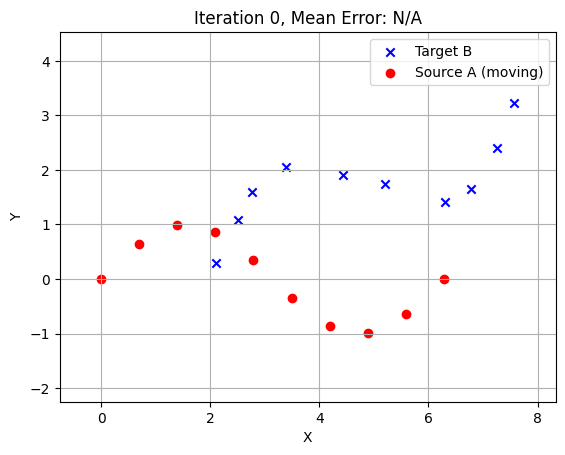

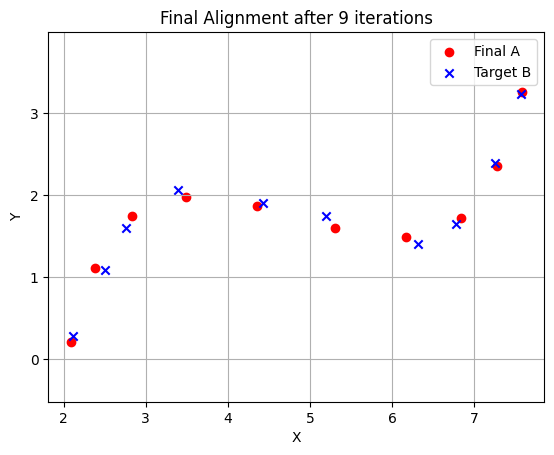

'"\nReference: https://github.com/OmarJItani/Iterative-Closest-Point-Algorithm/tree/main\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# import icp
import matplotlib.animation as animation
import copy # Needed for deep copies if modifying arrays in place later



# Define two sets of points A and B (same as your example)
t = np.linspace(0, 2*np.pi, 10)
A = np.column_stack((t, np.sin(t)))

# Define the rotation angle
theta = np.radians(30)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array(((c, -s), (s, c)))

# Define translation vector
translation_vector = np.array([[2, 0]])

# Apply the transformation and add randomness to get B
np.random.seed(42) # for reproducible randomness
randomness = 0.3 * np.random.rand(10, 2)
B = np.dot(rotation_matrix, A.T).T + translation_vector + randomness

# --- Run ICP and get history ---
max_iter = 20
tolerance = 0.0001 # Lower tolerance for smoother convergence potentially
T_final, history_A, history_error, iters = iterative_closest_point_visual(A, B, max_iterations=max_iter, tolerance=tolerance)

print(f'Converged/Stopped after {iters} iterations.')
print(f'Final Mean Error: {history_error[-1]:.4f}')
print('Final Transformation:')
print(np.round(T_final, 3))

# --- Create Animation ---
fig, ax = plt.subplots()

# Plot target points (static)
ax.scatter(B[:, 0], B[:, 1], color='blue', label='Target B', marker='x')

# Plot initial source points
scatter_A = ax.scatter(history_A[0][:, 0], history_A[0][:, 1], color='red', label='Source A (moving)')
title = ax.set_title(f'Iteration 0, Mean Error: N/A')
ax.legend()
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis('equal') # Important for visualizing rotations correctly

# Determine plot limits based on all points across all iterations
all_points = np.vstack([B] + history_A)
min_vals = np.min(all_points, axis=0)
max_vals = np.max(all_points, axis=0)
range_vals = max_vals - min_vals
margin = 0.1 * range_vals # Add 10% margin
ax.set_xlim(min_vals[0] - margin[0], max_vals[0] + margin[0])
ax.set_ylim(min_vals[1] - margin[1], max_vals[1] + margin[1])


# Animation update function
def update(frame):
    # Update source points position
    scatter_A.set_offsets(history_A[frame])
    # Update title
    error_str = f"{history_error[frame-1]:.4f}" if frame > 0 else "N/A" # Error calculated *after* step
    title.set_text(f'Iteration {frame}, Mean Error: {error_str}')
    # Return the artists that were modified
    return scatter_A, title,

# Create the animation
# Number of frames is number of states stored (initial + iterations)
# Interval is milliseconds between frames (e.g., 500ms = 0.5s)
ani = animation.FuncAnimation(fig, update, frames=len(history_A),
                              interval=500, blit=True, repeat=False)

# # --- Save the animation ---
# # You might need to install ffmpeg: conda install ffmpeg or sudo apt-get install ffmpeg
# try:
#     output_filename = 'icp_iterations.mp4'
#     ani.save(output_filename, writer='ffmpeg', fps=2) # fps = frames per second
#     print(f"Animation saved successfully as {output_filename}")
# except Exception as e:
#     print(f"Error saving animation: {e}")
#     print("Ensure ffmpeg is installed and accessible in your system's PATH.")
#     print("Alternatively, try saving as GIF (may require 'imagemagick' or 'pillow'):")
#     # try:
#     #     ani.save('icp_iterations.gif', writer='pillow', fps=2)
#     #     print("Animation saved successfully as icp_iterations.gif")
#     # except Exception as e_gif:
#     #     print(f"Error saving GIF: {e_gif}")


# Display the final plot (optional, animation already shows it)
plt.figure()
plt.scatter(history_A[-1][:, 0], history_A[-1][:, 1], color='red', label='Final A')
plt.scatter(B[:, 0], B[:, 1], color='blue', label='Target B', marker='x')
plt.legend()
plt.title(f"Final Alignment after {iters} iterations")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()





""""
Reference: https://github.com/OmarJItani/Iterative-Closest-Point-Algorithm/tree/main
"""
